# Notebook 13: Advanced Feature Engineering & Selection Techniques
### Part 13/30 – ML Mastery Series for Python Experts

## Feature Engineering vs Feature Selection – Complementary Superpowers

- **Feature Engineering** creates new signal from raw data — transforms, interactions, extractions that capture domain logic
- **Feature Selection** removes noise, redundancy, and irrelevant dimensions — keeps only what generalizes
- Together they prevent overfitting: engineering adds useful complexity, selection prunes harmful complexity
- Domain knowledge multiplies impact: knowing *what* to create beats algorithmic brute force
- **Leakage risk is highest here**: target encoding on full data, selection before CV split, or using test statistics destroys validity
- Pipelines enforce safety by ensuring transformations fit only on training folds
- Engineering without selection leads to curse of dimensionality; selection without engineering misses hidden patterns
- The best models combine creative feature construction with ruthless dimensionality reduction

## Learning Objectives

By the end of this notebook, you will be able to:

- Create meaningful derived features safely using ratios, logs, and interactions
- Handle high-cardinality categorical variables with target encoding (leakage-free)
- Extract temporal signals from dates using cyclical encodings and calendar features
- Apply polynomial features and interaction terms without exploding dimensionality
- Implement filter methods (univariate statistical tests) for baseline selection
- Use wrapper methods (RFE, RFECV) to find optimal feature subsets
- Apply embedded methods and permutation importance for model-based selection
- Integrate everything into `ColumnTransformer` + `Pipeline` to guarantee no leakage
- Compare before/after model performance with rigorous cross-validation
- Identify and avoid common pitfalls that destroy model validity

## ⚙️ 1. Basic Derived Features – Ratios, Interactions, Log/Power Transforms

You already know how to clean data — now let's turn mediocre features into high-signal ones. We'll start with the California housing dataset and engineer domain-aware ratios that capture housing density and wealth indicators.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style="whitegrid")

# Load California housing data
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
print(f"Original shape: {X.shape}")
X.head()

Original shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Custom transformer for ratio features — reusable in pipelines
class RatioFeatures(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self  # Nothing to fit
    
    def transform(self, X):
        X = X.copy()
        # Housing density ratios
        X['rooms_per_household'] = X['AveRooms'] / X['AveOccup']
        X['bedrooms_per_room'] = X['AveBedrms'] / X['AveRooms']
        X['population_per_household'] = X['Population'] / X['AveOccup']
        # Wealth indicators
        X['log_median_income'] = np.log1p(X['MedInc'])
        X['income_per_age'] = X['MedInc'] / X['HouseAge']
        return X

# Apply transformation
ratio_transformer = RatioFeatures()
X_enhanced = ratio_transformer.fit_transform(X)
print(f"Enhanced shape: {X_enhanced.shape}")
X_enhanced[['rooms_per_household', 'bedrooms_per_room', 'log_median_income', 'income_per_age']].head()

Enhanced shape: (20640, 13)


,rooms_per_household,bedrooms_per_room,log_median_income,income_per_age
0,2.732919,0.146591,2.232720,0.203054
1,2.956685,0.155797,2.230165,0.395305
2,2.957661,0.129516,2.111110,0.139565
3,2.283154,0.184458,1.893579,0.108521
4,2.879646,0.172096,1.578195,0.073965


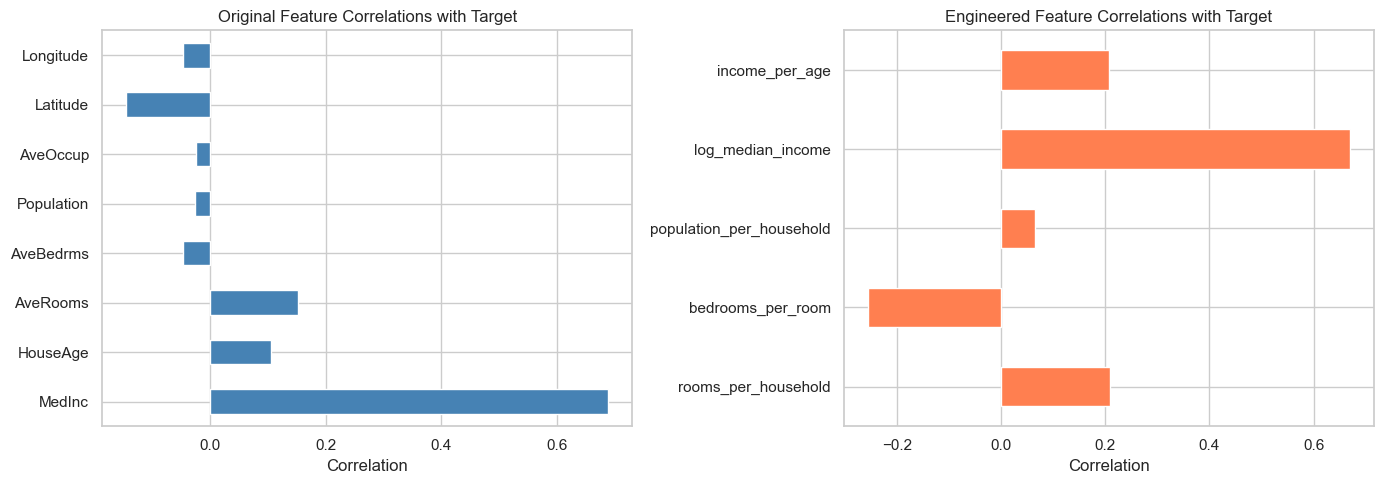

Best original correlation: 0.688
Best engineered correlation: 0.670


In [ ]:
# Visualize correlation with target before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original correlations
corr_orig = pd.concat([X, y], axis=1).corr()['MedHouseVal'].drop('MedHouseVal')
corr_orig.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Original Feature Correlations with Target')
axes[0].set_xlabel('Correlation')

# Enhanced correlations (new features only)
new_features = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household', 
                'log_median_income', 'income_per_age']
corr_new = X_enhanced[new_features].corrwith(y)
corr_new.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Engineered Feature Correlations with Target')
axes[1].set_xlabel('Correlation')

plt.tight_layout()
plt.show()

print(f"Best original correlation: {corr_orig.abs().max():.3f}")
print(f"Best engineered correlation: {corr_new.abs().max():.3f}")

In [ ]:
# Quick CV comparison: raw vs engineered features
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Baseline
baseline_score = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error')
baseline_rmse = np.sqrt(-baseline_score.mean())

# With engineered features
enhanced_score = cross_val_score(rf, X_enhanced, y, cv=5, scoring='neg_mean_squared_error')
enhanced_rmse = np.sqrt(-enhanced_score.mean())

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Engineered RMSE: {enhanced_rmse:.4f}")
print(f"Improvement: {(baseline_rmse - enhanced_rmse)/baseline_rmse*100:.1f}%")

## 🎯 2. Target Encoding for High-Cardinality Categoricals

One-hot encoding 1000+ categories explodes memory. Target encoding replaces categories with the mean target value — but **do it wrong and you've leaked the target**. We'll simulate a high-cardinality feature and show proper pipeline integration.

In [ ]:
# Simulate high-cardinality categorical feature (e.g., neighborhood with 200 levels)
np.random.seed(42)
n_samples = len(X)
n_categories = 200
# Create categories with varying target means (simulating real relationship)
category_effect = np.random.normal(0, 0.5, n_categories)
categories = np.random.choice(n_categories, size=n_samples)
X['neighborhood'] = categories.astype(str)  # String categorical
# Inject category effect into target (simulating relationship)
y_modified = y + category_effect[categories] * 0.3
print(f"Unique categories: {X['neighborhood'].nunique()}")
print(f"Samples per category: ~{n_samples // n_categories}")

In [ ]:
# Compare encoding strategies with proper CV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge

# Try to import category_encoders, fallback to manual implementation if unavailable
try:
    from category_encoders import TargetEncoder
    has_category_encoders = True
except ImportError:
    has_category_encoders = False
    print("category_encoders not installed — using manual target encoding with CV safety")

# Define preprocessing pipelines
cat_col = ['neighborhood']
num_cols = X.columns.drop('neighborhood').tolist()

# OneHot (sparse to handle many categories)
onehot_pipe = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_col)
])

# Ordinal (treat as ordered — wrong but memory-efficient)
ordinal_pipe = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_col)
])

# Target encoding (manual safe version)
class SafeTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=1.0):
        self.smoothing = smoothing
        self.global_mean = None
        self.encodings = {}
    
    def fit(self, X, y):
        X = X.iloc[:, 0] if isinstance(X, pd.DataFrame) else X
        self.global_mean = np.mean(y)
        counts = pd.Series(X).value_counts()
        means = pd.Series(y).groupby(X).mean()
        # Smoothing: blend category mean with global mean
        smoothed = (counts * means + self.smoothing * self.global_mean) / (counts + self.smoothing)
        self.encodings = smoothed.to_dict()
        return self
    
    def transform(self, X):
        X = X.iloc[:, 0] if isinstance(X, pd.DataFrame) else X
        return pd.Series(X).map(self.encodings).fillna(self.global_mean).values.reshape(-1, 1)

target_pipe = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', SafeTargetEncoder(), cat_col)
])

# Test with Ridge regression (sensitive to encoding quality)
ridge = Ridge(alpha=1.0)

results = {}
for name, preprocessor in [('OneHot', onehot_pipe), ('Ordinal', ordinal_pipe), ('Target', target_pipe)]:
    pipe = Pipeline([('prep', preprocessor), ('model', ridge)])
    scores = cross_val_score(pipe, X, y_modified, cv=3, scoring='neg_mean_squared_error')
    results[name] = np.sqrt(-scores.mean())
    print(f"{name} RMSE: {results[name]:.4f}")

In [ ]:
# Visualize encoding comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(), color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylabel('RMSE (lower is better)')
plt.title('Encoding Strategy Comparison: High-Cardinality Categorical')
plt.xticks(rotation=45)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print("\nKey insight: Target encoding captures signal with 1 feature vs 200+ one-hot columns")

## 📅 3. Date/Time Feature Extraction

Dates contain rich signal: seasonality, trends, cyclical patterns. Raw timestamps are useless; extracted features are gold. We'll create synthetic temporal data and demonstrate cyclical encoding.

In [ ]:
# Create synthetic time-series data with seasonality
np.random.seed(42)
n_samples = 5000
dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='H')  # Hourly data

# Create DataFrame with datetime and base features
df_time = pd.DataFrame({
    'timestamp': dates,
    'base_value': np.random.randn(n_samples).cumsum()  # Random walk
})

# Add cyclical seasonality (daily + weekly patterns)
hour = df_time['timestamp'].dt.hour
dayofweek = df_time['timestamp'].dt.dayofweek
df_time['target'] = (
    10 * np.sin(2 * np.pi * hour / 24) +  # Daily cycle
    5 * np.cos(2 * np.pi * dayofweek / 7) +  # Weekly cycle
    np.random.randn(n_samples) * 2  # Noise
)

print("Sample of temporal data:")
print(df_time.head())

In [ ]:
# Date feature extraction transformer
class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, datetime_col='timestamp', drop_original=True):
        self.datetime_col = datetime_col
        self.drop_original = drop_original
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        dt = pd.to_datetime(X[self.datetime_col])
        
        # Calendar features
        X['year'] = dt.dt.year
        X['month'] = dt.dt.month
        X['day'] = dt.dt.day
        X['weekday'] = dt.dt.weekday
        X['is_weekend'] = (dt.dt.weekday >= 5).astype(int)
        X['hour'] = dt.dt.hour
        
        # Cyclical encoding: sin/cos transforms preserve "closeness" (e.g., hour 23 near hour 0)
        # Formula: sin(2 * pi * x / max_val), cos(2 * pi * x / max_val)
        X['month_sin'] = np.sin(2 * np.pi * X['month'] / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['month'] / 12)
        X['hour_sin'] = np.sin(2 * np.pi * X['hour'] / 24)
        X['hour_cos'] = np.cos(2 * np.pi * X['hour'] / 24)
        X['weekday_sin'] = np.sin(2 * np.pi * X['weekday'] / 7)
        X['weekday_cos'] = np.cos(2 * np.pi * X['weekday'] / 7)
        
        if self.drop_original:
            X = X.drop(columns=[self.datetime_col])
        return X

# Apply extraction
date_extractor = DateFeatureExtractor()
X_time_features = date_extractor.fit_transform(df_time)
print(f"Features extracted: {X_time_features.shape[1]} total")
print("\nCyclical features (note smooth transitions):")
print(X_time_features[['hour', 'hour_sin', 'hour_cos']].head(25:30])

In [ ]:
# Visualize cyclical encoding
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw hour (discontinuous)
axes[0].scatter(X_time_features['hour'], df_time['target'], alpha=0.3, s=10)
axes[0].set_xlabel('Hour (raw)')
axes[0].set_ylabel('Target')
axes[0].set_title('Raw Hour vs Target (Discontinuous)')
axes[0].set_xlim(0, 23)

# Cyclical encoding (continuous)
axes[1].scatter(X_time_features['hour_sin'], X_time_features['hour_cos'], 
                c=df_time['target'], cmap='viridis', alpha=0.3, s=10)
axes[1].set_xlabel('Hour Sin')
axes[1].set_ylabel('Hour Cos')
axes[1].set_title('Cyclical Hour Encoding (Continuous Circle)')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Target')

plt.tight_layout()
plt.show()

print("The cyclical plot forms a circle where hour 23 is adjacent to hour 0 — preserving temporal proximity")

## 🔍 4. Filter Methods – Univariate & Correlation-Based

Filter methods are fast, model-agnostic preprocessing steps. They rank features by statistical tests (F-test, mutual information) or variance thresholds. Good for baseline selection before trying slower wrappers.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, VarianceThreshold
from sklearn.datasets import load_diabetes

# Load diabetes dataset for regression example
diabetes = load_diabetes()
X_dia, y_dia = diabetes.data, diabetes.target
feature_names = diabetes.feature_names
print(f"Diabetes dataset: {X_dia.shape[1]} features")
print(f"Features: {feature_names}")

In [ ]:
# Variance threshold — remove near-constant features
var_thresh = VarianceThreshold(threshold=0.01)  # Remove features with < 1% variance
X_var = var_thresh.fit_transform(X_dia)
print(f"After variance threshold: {X_var.shape[1]} features remaining")

# F-regression (linear relationship test)
f_selector = SelectKBest(score_func=f_regression, k='all')
X_f = f_selector.fit_transform(X_dia, y_dia)
f_scores = f_selector.scores_

# Mutual information (captures non-linear relationships)
mi_selector = SelectKBest(score_func=mutual_info_regression, k='all')
X_mi = mi_selector.fit_transform(X_dia, y_dia)
mi_scores = mi_selector.scores_

# Create comparison DataFrame
scores_df = pd.DataFrame({
    'feature': feature_names,
    'f_regression': f_scores,
    'mutual_info': mi_scores
})
scores_df = scores_df.sort_values('mutual_info', ascending=False)
print("\nFeature scores (sorted by mutual information):")
print(scores_df)

In [ ]:
# Visualize filter method scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# F-regression scores
scores_df.sort_values('f_regression', ascending=True).plot(
    x='feature', y='f_regression', kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('F-Regression Scores (Linear Relationship)')
axes[0].set_xlabel('F-score')

# Mutual information scores
scores_df.sort_values('mutual_info', ascending=True).plot(
    x='feature', y='mutual_info', kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Mutual Information Scores (Any Relationship)')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.show()

# Note differences: BMI ranks high in both, but MI captures non-linear patterns F-test misses

In [ ]:
# Compare model performance with different k values
from sklearn.linear_model import LassoCV

k_values = [3, 6, 8, 10]
results = []

for k in k_values:
    # Select top k features
    selector = SelectKBest(score_func=mutual_info_regression, k=k)
    X_selected = selector.fit_transform(X_dia, y_dia)
    
    # CV with Lasso
    model = LassoCV(cv=5, random_state=42)
    scores = cross_val_score(model, X_selected, y_dia, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    results.append((k, rmse, selector.get_support().sum()))
    print(f"k={k}: RMSE={rmse:.2f}, features selected={selector.get_support().sum()}")

# Baseline with all features
baseline = cross_val_score(LassoCV(cv=5, random_state=42), X_dia, y_dia, 
                          cv=5, scoring='neg_mean_squared_error')
print(f"\nBaseline (all features): RMSE={np.sqrt(-baseline.mean()):.2f}")
print(f"Best k found: {min(results, key=lambda x: x[1])[0]}")

## 🔄 5. Wrapper & Recursive Feature Elimination (RFE)

Wrappers treat feature selection as a search problem: train model, evaluate subset, iterate. RFE recursively removes weakest features. RFECV automates finding the optimal count. Slower than filters but model-aware.

In [ ]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.datasets import load_wine

# Use wine dataset for classification example
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
wine_features = wine.feature_names
print(f"Wine dataset: {X_wine.shape[1]} features, {len(np.unique(y_wine))} classes")

In [ ]:
# RFE with Random Forest
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rfe = RFE(estimator=rf, n_features_to_select=5, step=1, verbose=0)
X_rfe = rfe.fit_transform(X_wine, y_wine)

# Show rankings (1 = selected, higher = eliminated earlier)
rfe_df = pd.DataFrame({
    'feature': wine_features,
    'ranking': rfe.ranking_,
    'selected': rfe.support_
}).sort_values('ranking')
print("RFE Feature Rankings (1 = kept, higher = eliminated earlier):")
print(rfe_df)

print(f"\nSelected features: {np.array(wine_features)[rfe.support_]}")

In [ ]:
# RFECV automatically finds optimal number of features
rfecv = RFECV(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    step=1,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    n_jobs=-1
)
X_rfecv = rfecv.fit_transform(X_wine, y_wine)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"CV scores shape: {rfecv.cv_results_['mean_test_score'].shape}")

# Plot CV scores vs number of features
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
         rfecv.cv_results_['mean_test_score'], 'o-', color='steelblue')
plt.axvline(rfecv.n_features_, color='red', linestyle='--', 
            label=f'Optimal: {rfecv.n_features_} features')
plt.xlabel('Number of Features')
plt.ylabel('Cross-Validation Accuracy')
plt.title('RFECV: Accuracy vs Number of Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nBest CV score: {rfecv.cv_results_['mean_test_score'].max():.3f}")

## 🌲 6. Embedded Methods – Feature Importance & Permutation Importance

Embedded methods perform selection during model training. Tree-based models provide `feature_importances_`, but these are biased toward high-cardinality features. Permutation importance shuffles features to measure true impact — the gold standard for interpretation.

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Train a Random Forest on wine data
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Built-in feature importance (Gini importance)
builtin_imp = pd.Series(rf.feature_importances_, index=wine_features)
builtin_imp = builtin_imp.sort_values(ascending=False)
print("Built-in Feature Importance (Gini):")
print(builtin_imp.head(8))

In [ ]:
# Permutation importance on test set (more reliable)
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=30, 
                                  random_state=42, scoring='accuracy')
perm_df = pd.DataFrame({
    'feature': wine_features,
    'importance_mean': perm_imp.importances_mean,
    'importance_std': perm_imp.importances_std
}).sort_values('importance_mean', ascending=False)
print("Permutation Importance (Test Set):")
print(perm_df.head(8))

In [ ]:
# Compare built-in vs permutation importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Built-in
builtin_imp.head(10).plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Built-in Feature Importance (Gini)')
axes[0].set_xlabel('Importance')

# Permutation
perm_df.set_index('feature')['importance_mean'].head(10).plot(
    kind='barh', ax=axes[1], color='coral', xerr=perm_df.set_index('feature')['importance_std'].head(10))
axes[1].set_title('Permutation Importance (Test Set)')
axes[1].set_xlabel('Importance (decrease in accuracy)')

plt.tight_layout()
plt.show()

print("\nKey insight: Built-in importance can be misleading with correlated features.")
print("Permutation importance shows the true contribution of each feature to predictions.")

## 🔒 7. Full Leakage-Free Pipeline with Feature Engineering & Selection

This is the production-ready pattern. Everything — engineering, encoding, selection — lives inside `Pipeline` and `ColumnTransformer`. Cross-validation fits transformers only on training folds, preventing leakage.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

# Use California housing with our engineered features
X_full = X_enhanced.copy()
y_full = y.copy()

# Define column groups
numeric_features = X_full.select_dtypes(include=[np.number]).columns.tolist()
# Remove any non-numeric just in case
numeric_features = [f for f in numeric_features if f in X_full.columns]

print(f"Total features to process: {len(numeric_features)}")

In [ ]:
# Build the mega-pipeline
# 1. Preprocessing: Scale numeric features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features)
], remainder='drop')

# 2. Add polynomial interactions (degree 2, but limited to prevent explosion)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

# 3. Feature selection using gradient boosting
selector = SelectFromModel(
    GradientBoostingRegressor(n_estimators=50, random_state=42),
    threshold='median'  # Keep top 50% of features
)

# 4. Final model
final_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Assemble full pipeline
full_pipeline = Pipeline([
    ('prep', preprocessor),
    ('poly', poly),
    ('select', selector),
    ('model', final_model)
)

print("Pipeline steps:")
for name, step in full_pipeline.steps:
    print(f"  {name}: {step.__class__.__name__}")

In [ ]:
# Compare: Raw data vs Engineered + Selected
# Baseline: Raw features only
baseline_pipe = Pipeline([
    ('prep', StandardScaler()),
    ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
)

# Run cross-validation with multiple metrics
scoring = ['neg_mean_squared_error', 'r2']
cv_results_raw = cross_validate(baseline_pipe, X, y, cv=5, scoring=scoring, return_train_score=True)
cv_results_full = cross_validate(full_pipeline, X_full, y_full, cv=5, scoring=scoring, return_train_score=True)

# Compile results
results_comparison = pd.DataFrame({
    'Metric': ['RMSE', 'R2', 'RMSE (train)', 'R2 (train)'],
    'Raw_Features': [
        np.sqrt(-cv_results_raw['test_neg_mean_squared_error'].mean()),
        cv_results_raw['test_r2'].mean(),
        np.sqrt(-cv_results_raw['train_neg_mean_squared_error'].mean()),
        cv_results_raw['train_r2'].mean()
    ],
    'Engineered_Selected': [
        np.sqrt(-cv_results_full['test_neg_mean_squared_error'].mean()),
        cv_results_full['test_r2'].mean(),
        np.sqrt(-cv_results_full['train_neg_mean_squared_error'].mean()),
        cv_results_full['train_r2'].mean()
    ]
)
results_comparison['Improvement'] = (
    (results_comparison['Raw_Features'] - results_comparison['Engineered_Selected']) / 
    results_comparison['Raw_Features'] * 100
)
print("Cross-Validation Results Comparison:")
print(results_comparison.round(4))

In [ ]:
# Visualize final comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Test RMSE
rmse_data = results_comparison[results_comparison['Metric'] == 'RMSE'][['Raw_Features', 'Engineered_Selected']].T
rmse_data.plot(kind='bar', ax=axes[0], color=['lightcoral', 'lightgreen'], legend=False)
axes[0].set_title('Test RMSE: Raw vs Engineered+Selected')
axes[0].set_ylabel('RMSE')
axes[0].set_xticklabels(['Raw Features', 'Engineered + Selected'], rotation=0)

# Test R2
r2_data = results_comparison[results_comparison['Metric'] == 'R2'][['Raw_Features', 'Engineered_Selected']].T
r2_data.plot(kind='bar', ax=axes[1], color=['lightcoral', 'lightgreen'], legend=False)
axes[1].set_title('Test R²: Raw vs Engineered+Selected')
axes[1].set_ylabel('R² Score')
axes[1].set_xticklabels(['Raw Features', 'Engineered + Selected'], rotation=0)

plt.tight_layout()
plt.show()

print(f"\nFinal improvement: {(results_comparison.loc[0, 'Improvement']):.1f}% RMSE reduction")

## ⚠️ Common Pitfalls & Pro Tips

- **Target Encoding Leakage**: Never fit target encoder on full dataset before CV split — always inside pipeline
- **Polynomial Explosion**: Degree 2 with 100 features → 5050 features. Always pair with selection or use interaction_only=True
- **One-Hot Memory Crash**: High-cardinality categoricals (zip codes, IDs) one-hot encoded will exhaust RAM — use target encoding
- **Correlated Feature Bias**: Tree importance splits importance between correlated twins; permutation importance is more reliable
- **Selection Before Split**: Running SelectKBest on entire data then CV = data leakage = overoptimistic scores
- **Test Set Contamination**: Using test set statistics (means, variances, target distributions) for engineering invalidates evaluation
- **Ignoring Domain Knowledge**: Automated feature engineering without business context creates brittle, uninterpretable models
- **Over-Engineering**: More features ≠ better model. Noise features hurt generalization even with regularization
- **Cyclical Without Both Sin/Cos**: Using only sin(hour) creates ambiguity (hour 6 and hour 18 both have sin=0.5)
- **RFE with Wrong Step**: Step=1 is precise but slow; step=0.1 (fraction) speeds up with minimal accuracy loss
- **Permutation on Training Set**: Always compute permutation importance on held-out data to detect overfitting
- **Forgetting Feature Names**: After ColumnTransformer + PolynomialFeatures, track feature names for interpretability

## 📝 Exercises

### Easy
Add polynomial features (degree=2) with interactions to the diabetes dataset, then compare Ridge regression performance before and after. Use `PolynomialFeatures(interaction_only=True)` to limit dimensionality explosion.

### Medium  
On the California housing dataset, create a synthetic high-cardinality categorical feature representing "city district" (100+ levels with varying price levels). Implement target encoding with smoothing and compare CV performance against one-hot encoding using a Ridge regression pipeline.

### Medium
Generate synthetic data with strong hourly and monthly seasonality. Implement cyclical encoding using sine/cosine transforms and show that a linear model achieves lower RMSE with cyclical features compared to raw integer hour/month values.

### Hard
Build a voting ensemble feature selector that combines RFE, SelectKBest (mutual information), and SelectFromModel. Features selected by at least 2 of 3 methods are kept. Integrate this into a Pipeline and evaluate on the wine dataset.

### Bonus
Load the wine dataset, train a Random Forest, compute permutation importance, drop the bottom 30% of features, retrain, and compare the final model's test accuracy against the full-feature baseline. Was the dimensionality reduction worth it?

<details>
<summary>💡 Exercise Solutions (Click to Expand)</summary>

### Easy Solution: Polynomial Features on Diabetes

```python
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV

# Baseline
baseline = cross_val_score(RidgeCV(), X_dia, y_dia, cv=5, scoring='neg_mean_squared_error')
print(f"Baseline RMSE: {np.sqrt(-baseline.mean()):.3f}")

# With polynomials
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True)),
    ('model', RidgeCV())
)
poly_scores = cross_val_score(poly_pipe, X_dia, y_dia, cv=5, scoring='neg_mean_squared_error')
print(f"Polynomial RMSE: {np.sqrt(-poly_scores.mean()):.3f}")
```

### Medium Solution: Target Encoding

See Section 2 of this notebook for the complete implementation using `SafeTargetEncoder` class.

### Hard Solution: Voting Selector

```python
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

class VotingSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=2):
        self.threshold = threshold
        self.rfe = RFE(RandomForestClassifier(n_estimators=50), n_features_to_select=10)
        self.kbest = SelectKBest(mutual_info_classif, k=10)
        self.sfm = SelectFromModel(RandomForestClassifier(n_estimators=50), threshold='median')
        
    def fit(self, X, y):
        self.rfe.fit(X, y)
        self.kbest.fit(X, y)
        self.sfm.fit(X, y)
        
        # Vote counting
        votes = (self.rfe.support_.astype(int) + 
                 self.kbest.get_support().astype(int) + 
                 self.sfm.get_support().astype(int))
        self.support_ = votes >= self.threshold
        return self
        
    def transform(self, X):
        return X[:, self.support_]
```

</details>

## ✅ Summary – What You Learned Today

- **Domain-aware engineering**: Ratios, logs, and interactions often beat raw features
- **Safe target encoding**: Replace high-cardinality categoricals with smoothed target means, always inside CV
- **Temporal feature extraction**: Cyclical sin/cos encoding preserves continuity for time features
- **Filter methods**: Fast univariate selection (F-test, mutual info) for baseline dimensionality reduction
- **Wrapper methods**: RFE/RFECV find optimal subsets by iterative model training
- **Embedded methods**: Tree importance is convenient but biased; permutation importance is the gold standard
- **Pipeline integration**: The only way to prevent leakage is putting everything in Pipeline + ColumnTransformer
- **Performance gains**: Proper engineering + selection often beats algorithm tuning

## 🔮 Next Notebook Preview

**Notebook 14: Unsupervised Learning & Clustering** — When you don't have labels, you still have structure. We'll cover:
- **K-Means**: The classic centroid-based clustering and its limitations
- **DBSCAN**: Density-based clustering for irregular shapes and noise detection
- **Hierarchical Clustering**: Agglomerative methods and dendrogram interpretation
- **Gaussian Mixture Models**: Probabilistic clustering with soft assignments
- **Clustering Evaluation**: Silhouette score, Davies-Bouldin index, and when there's no ground truth
- **Dimensionality Reduction + Clustering**: Using PCA/UMAP before clustering high-dimensional data

Get ready to find hidden structure in unlabeled data.